In [ ]:
#librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf
import statsmodels.api as sm
from scipy import stats
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


# Tratamiento del dataset y análisis

In [ ]:
# Cargando el dataset
!wget https://raw.githubusercontent.com/plotly/datasets/502daad486f112310367a20a74a00a9cc6e75240/diabetes.csv

df = pd.read_csv('diabetes.csv')

--2023-08-13 15:38:29--  https://raw.githubusercontent.com/plotly/datasets/502daad486f112310367a20a74a00a9cc6e75240/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv.2’

diabetes.csv.2      100%[===================>]  23.31K  --.-KB/s    in 0s      

2023-08-13 15:38:29 (104 MB/s) - ‘diabetes.csv.2’ saved [23873/23873]



### Los datos representan lo siguiente
<table>
<thead>
<tr>
<th>Columna</th>
<th>Descripción</th>
</tr>
</thead>
<tbody>
<tr>
<td>Pregnancies</td>
<td>Expresa el número de embarazos</td>
</tr>
<tr>
<td>Glucose</td>
<td>Expresa el nivel de glucosa en sangre</td>
</tr>
<tr>
<td>BloodPressure</td>
<td>Expresa la medición de la presión arterial</td>
</tr>
<tr>
<td>SkinThickness</td>
<td>Expresa el grosor de la piel</td>
</tr>
<tr>
<td>Insulin</td>
<td>Exoresa el nivel de insulina en sangre</td>
</tr>
<tr>
<td>BMI</td>
<td>Expresa el índice de masa corporal</td>
</tr>
<tr>
<td>DiabetesPedigreeFunction</td>
<td>Expresa el porcentaje de riesgo para la diabetes (basada en historial familiar)</td>
</tr>
<tr>
<td>Age</td>
<td>Expresa la edad</td>
</tr>
<tr>
<td>Outcome</td>
<td>Expresa el resultado final, 1 si tiene diabetes, 0 sino</td>
</tr>
</tbody>
</table>

In [ ]:
#Muestro las primeras 5 filas
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Hay valores muy grandes y muy chicos, se va a necesitar un reescalado de los mismos, un BatchNormalization

In [ ]:
#Summary de los datos
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Hay valores que dan 0 y que no respresentan nada.

### Primero analizemos por cuál valor podemos reemplazar estos resultados

In [ ]:
#Porcentaje de la cantidad de valores 0 por columna
df.isin([0]).sum()/len(df)*100

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

El espesor de la piel y la insulina presentan muchos valores iguales a 0 (más del 25%) se debería eliminar las columnas. El resto de columnas se deberá hacer análisis para reemplazar estos valores por una medida de centralidad

In [ ]:
df = df.drop(columns=['SkinThickness','Insulin'])
df

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,76,32.9,0.171,63,0
764,2,122,70,36.8,0.340,27,0
765,5,121,72,26.2,0.245,30,0
766,1,126,60,30.1,0.349,47,1


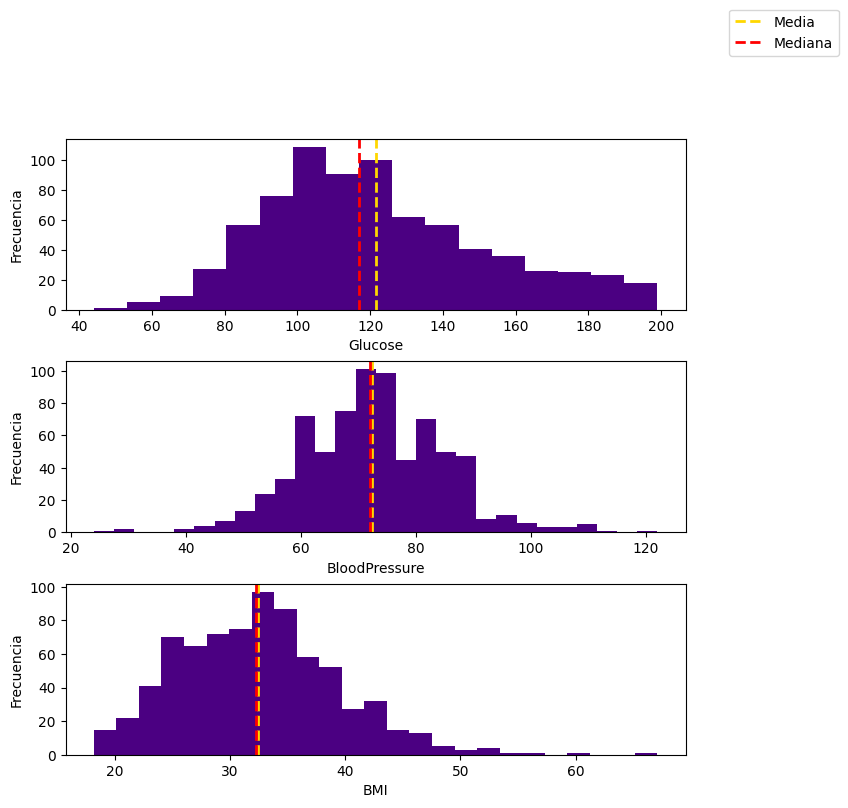

In [ ]:
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(hspace=0.3, wspace=0.5)

columnas = ['Glucose', 'BloodPressure', 'BMI']
medias = []
medianas = []
for j in range(3):
  plt.subplot(3, 1, j+1)
  #Elimino los valores 0 de la columna y hago un histograma para decidir si la mediana o la media representa a la muestra
  df_sin = df.drop(df.loc[df[columnas[j]]==0].index, inplace=False)
  plt.hist(df_sin[columnas[j]], bins='auto', color='indigo')
  media = df_sin[columnas[j]].mean()
  mediana = df_sin[columnas[j]].median()
  medias.append(media)
  medianas.append(mediana)
  plt.xlabel(columnas[j])
  plt.ylabel('Frecuencia')
  plt.axvline(x = media, color = 'gold', linestyle='--', linewidth=2)
  plt.axvline(x = mediana, color = 'r', linestyle='--', linewidth=2)
fig.legend(bbox_to_anchor=(1.1, 1.05), labels=['Media','Mediana'])
plt.show()

En base a esto se propone cambiar los valores por
<table>
<thead>
<tr>
<th>Columna</th>
<th>Reemplazo por</th>
</tr>
</thead>
<tbody>
<tr>
<td>Glucose</td>
<td>Media</td>
</tr>
<tr>
<td>BloodPressure</td>
<td>Mediana</td>
</tr>
<tr>
<td>BMI</td>
<td>Mediana</td>
</tr>
</tbody>
</table>

In [ ]:
reemplazos = {'Glucose': medias[0], 'BloodPressure': medianas[1],'BMI': medianas[2]}
df.replace(0, reemplazos, inplace=True)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.386719,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096642,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,67.100000,2.420000,81.000000,1.000000


## Para acelerar el entrenamiento conviene cambiar el tipo de datos de cada columna por lo que mejor ajuste a su rango de valores

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 42.1 KB


In [ ]:
#Analizando las columnas se propone hacer el siguiente cambio de tipo de datos
#uint8 = valores [0,255]
#float32 = valores flotantes con 32 bits (1 bit al signo, 8 al exponente, 23 de mantisa)
df = df.astype({'Pregnancies': 'uint8', 'Glucose': 'float32', 'BloodPressure': 'uint8','BMI': 'float32', 'DiabetesPedigreeFunction': 'float32', 'Age':'uint8','Outcome':'uint8'})

## Veamos el porcentaje de diabéticos

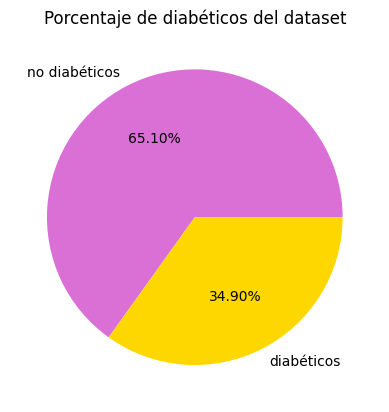

In [ ]:
plt.pie(df['Outcome'].value_counts(), labels=['no diabéticos','diabéticos'], autopct='%1.2f%%', colors=['orchid', 'gold'])
plt.title(label="Porcentaje de diabéticos del dataset")
plt.show()

## ¿La glucosa tiene una distribución normal?

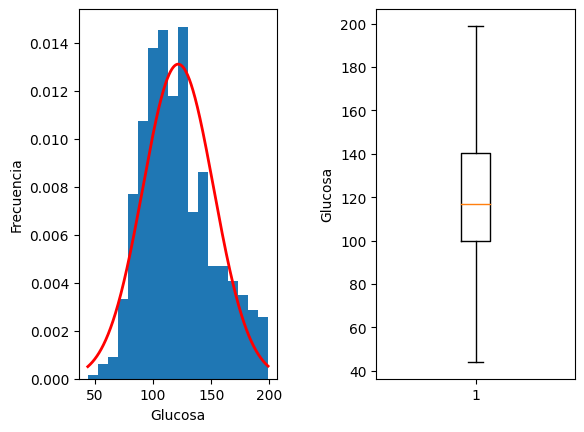

In [ ]:
#Veamos un histograma y boxplot
fig = plt.figure()
fig.subplots_adjust(hspace=0.3, wspace=0.5)

plt.subplot(1, 2, 1)
plt.hist(df['Glucose'], bins='auto', density=True)
x_axis = np.arange(df.Glucose.min(), df.Glucose.max(), 0.1)
plt.plot(x_axis, norm.pdf(x_axis, df.Glucose.mean(), df.Glucose.std()), linewidth=2, color='r')
plt.xlabel('Glucosa')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.boxplot(df['Glucose'])
plt.ylabel('Glucosa')

plt.show()

Parece que el histograma da con una cola más pesada a izquierda (cae más rápidamente) <br>

Por otro lado el boxplot da un resultado un poco asimétrico, la mediana no queda tan centrado como debería.
Pros: los brazos son parecidos

Figure(640x480)


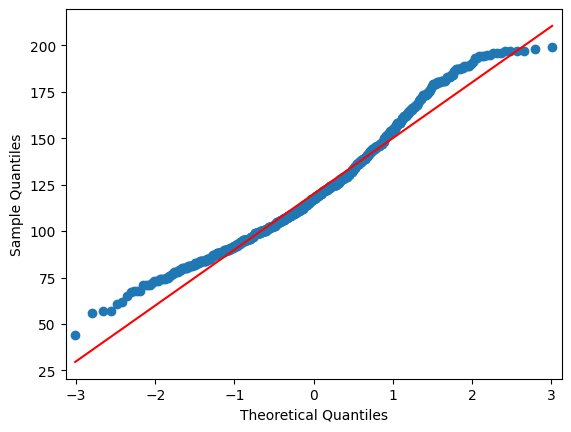

In [ ]:
#Haré un qqplot
print(sm.qqplot(df['Glucose'], line='q'))

Efectivamente, se tiene una cola pesada a izquierda y liviana a derecha (aunque abrupta). Podríamos concluir que la glucosa no tiene una distribución normal

Veamos un test de hipótesis para corroborar que no tiene una distribución normal

In [ ]:
from scipy.stats import shapiro

#Shapiro-Wilk test para ver si corresponde a una distribución normal
shapiro(df['Glucose'])

ShapiroResult(statistic=0.9699020385742188, pvalue=1.7770054525079182e-11)

El p-valor es muy chiquito, para cualquier nivel de significación aceptable se rechazaría la hipótesis nula de que la distrubición de la glucosa es normal

Sin embargo separando por diabéticos y no diabéticos se tiene una distribución más normal

<Axes: xlabel='Glucose', ylabel='Count'>

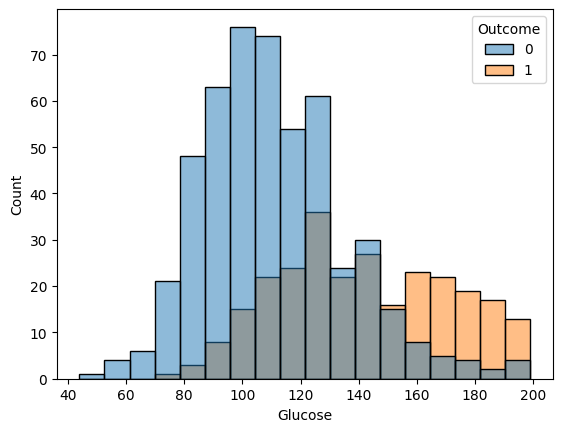

In [ ]:
sns.histplot(data=df,x='Glucose',hue='Outcome')

In [ ]:
print(shapiro(df.loc[df["Outcome"] == 0, "Glucose"]))
print(shapiro(df.loc[df["Outcome"] == 1, "Glucose"]))

ShapiroResult(statistic=0.9751465916633606, pvalue=1.6574750816289452e-07)
ShapiroResult(statistic=0.9740051627159119, pvalue=8.392198651563376e-05)


Volviendo hacer el Shapiro-Wilk test obtenemos un resultado mejor pero aún así no se tiene normalidad para un nivel de significación razonable

##¿Cuál es el máximo de embarazos?

In [ ]:
df['Pregnancies'].max()

17

¡Una mujer tuvo 17 embarazos!

## ¿La presión arterial tiene una distribución normal?

Text(0, 0.5, 'Presión arterial')

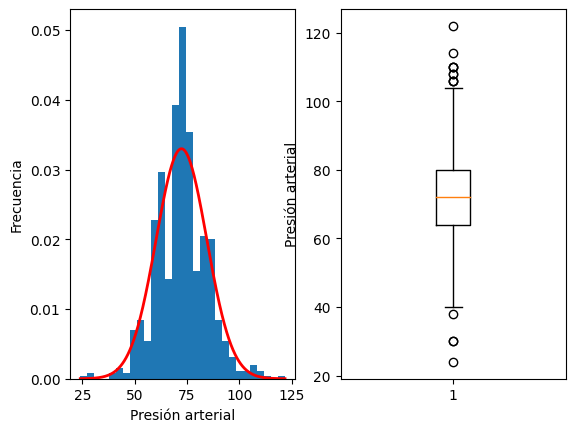

In [ ]:
#Veamos un histograma y boxplot
plt.subplot(1, 2, 1)
plt.hist(df['BloodPressure'], bins='auto', density=True)
x_axis = np.arange(df.BloodPressure.min(), df.BloodPressure.max(), 0.1)
plt.plot(x_axis, norm.pdf(x_axis, df.BloodPressure.mean(), df.BloodPressure.std()), linewidth=2, color='r')
plt.xlabel('Presión arterial')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.boxplot(df['BloodPressure'])
plt.ylabel('Presión arterial')

Tiene un compartamiento nada parecido a la de una normal, con muchos datos atípicos

In [ ]:
#Rango intercuartil
IQR = stats.iqr(df['BloodPressure'])
print(IQR)

16.0


Comrpobando con Shapiro-Wilk test

In [ ]:
print(shapiro(df['BloodPressure']))

ShapiroResult(statistic=0.9878172874450684, pvalue=5.2583964134100825e-06)


## Veamos la correlación entre columnas

<Axes: >

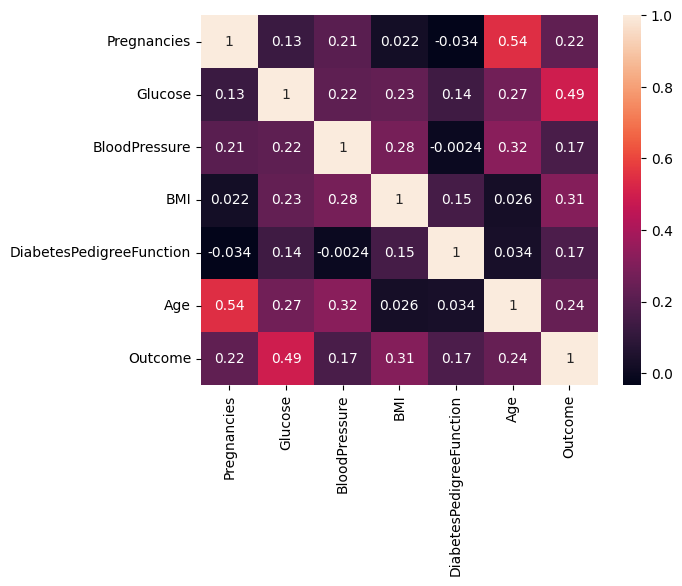

In [ ]:
sns.heatmap(df.corr(), annot=True)

Hay algo de correlación entre Glucosa e Insulina, BMI y Presión arterial; y BMI y diabéticos.
Hay una correlación considerable entre edad y embarazos, glucosa y diabéticos, grosor de la piel y BMI

Veamos la dispersión de los datos separados por diabéticos y no diabéticos

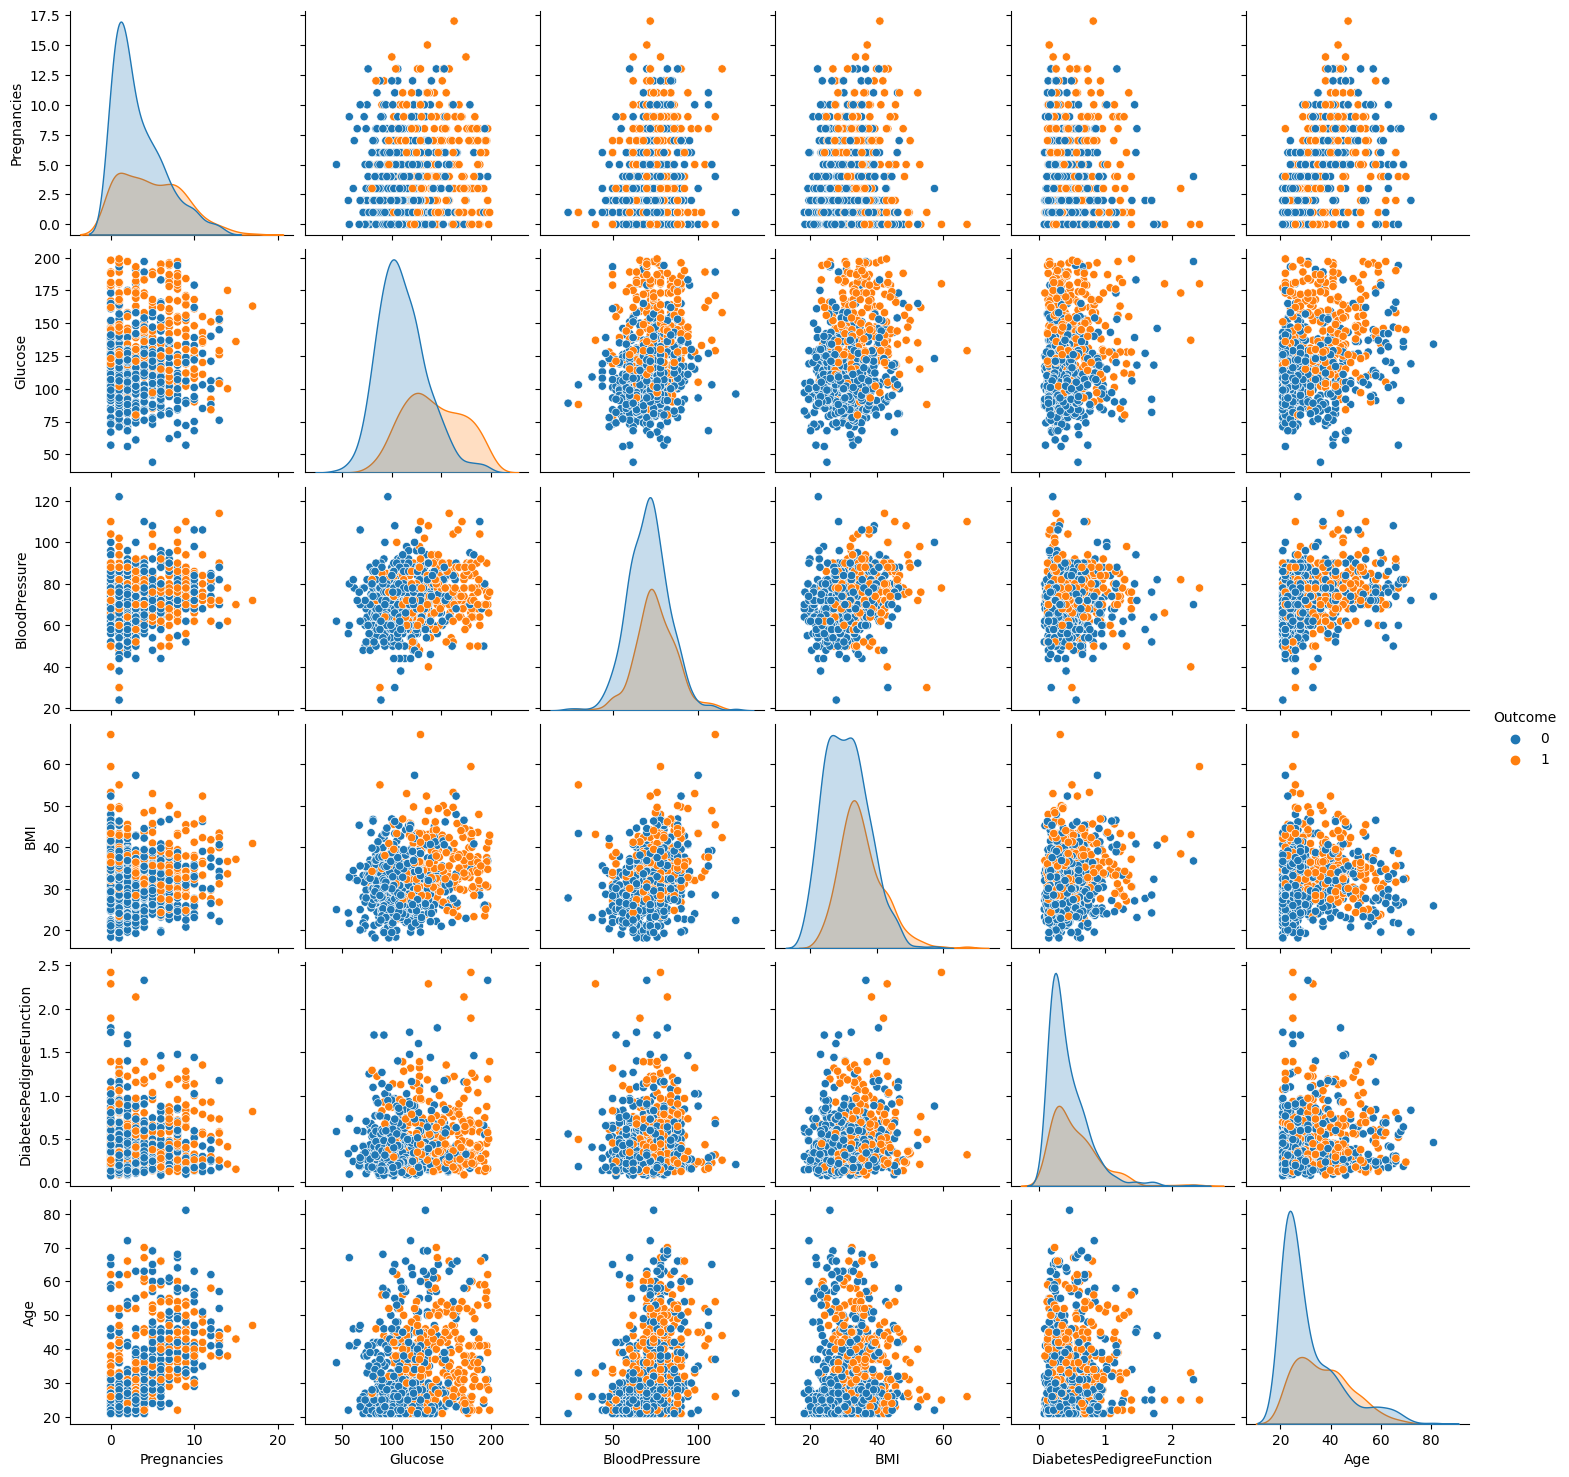

In [ ]:
 sns.pairplot(df,hue='Outcome')

## Info de los datos

In [ ]:
#Chequeamos que todos los valores son numéricos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    uint8  
 1   Glucose                   768 non-null    float32
 2   BloodPressure             768 non-null    uint8  
 3   BMI                       768 non-null    float32
 4   DiabetesPedigreeFunction  768 non-null    float32
 5   Age                       768 non-null    uint8  
 6   Outcome                   768 non-null    uint8  
dtypes: float32(3), uint8(4)
memory usage: 12.1 KB


No hay datos nulos y todos los valores son números, podemos empezar con los modelos

# Modelos con redes neuronales

In [ ]:
train_data = df.copy()
train_label = train_data.pop('Outcome')

Se plantean 3 modelos con diferentes parámetros para luego elegir uno que obtenga los mejores resultados (según unos criterios)

In [ ]:
threshold = 0.48
def modelo_(i):
  if i==1:
    #modelo 1
    model_1 = keras.Sequential([
        layers.Dense(124, input_shape=[len(train_data.keys())]),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(124, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(124, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid'),
    ])

    model_1.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", dtype=None, threshold=threshold),tf.keras.metrics.Precision(thresholds=threshold, name='Precision'),tf.keras.metrics.Recall(thresholds=threshold, name='Recall')],
        )
    return model_1
  if i==2:
    #modelo 2
    model_2 = keras.Sequential([
        layers.Dense(500, input_shape=[len(train_data.keys())]),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(500, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(500, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid'),
    ])

    model_2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", dtype=None, threshold=threshold),tf.keras.metrics.Precision(thresholds=threshold, name='Precision'),tf.keras.metrics.Recall(thresholds=threshold, name='Recall')],
        )
    return model_2
  if i==3:
    #modelo 3
    regularización = 0.4
    model_3 = keras.Sequential([
        layers.Dense(200, input_shape=[len(train_data.keys())], kernel_regularizer=regularizers.L2(regularización)),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(200, activation='relu', kernel_regularizer=regularizers.L2(regularización)),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(200, activation='relu', kernel_regularizer=regularizers.L2(regularización)),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(150, activation='relu', kernel_regularizer=regularizers.L2(regularización)),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(50, activation='relu', kernel_regularizer=regularizers.L2(regularización)),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid'),
    ])

    model_3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", dtype=None, threshold=threshold),tf.keras.metrics.Precision(thresholds=threshold, name='Precision'),tf.keras.metrics.Recall(thresholds=threshold, name='Recall')],
        )
    return model_3

## Veamos con cuál modelo nos quedamos, para ello hagamos k-fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from statistics import mean

#Uso una seed para poder obtener los mismos resultados al fraccionar los datos
seed = 12
#CV
kfold = StratifiedKFold(n_splits=7, shuffle=True, random_state=seed)
models_names = ['modelo 1','modelo 2','modelo 3']
for i in range(3):
  cvscores_acc = []
  cvscores_precision = []
  cvscores_recall = []
  t = 0
  if i != 0:
    print('\nAhora', models_names[i])
  else:
    print('Ahora', models_names[i])
  for train, test in kfold.split(train_data, train_label):
    model = modelo_(i+1)
    #Fit the model
    model.fit(train_data.iloc[train], train_label.iloc[train], epochs=150, batch_size=60, verbose=0)
    #evaluate the model
    scores = model.evaluate(train_data.iloc[test], train_label.iloc[test], verbose=0)
    print("%s: %.2f%%, %s: %.2f%% y %s: %.2f%%" % (model.metrics_names[1], scores[1]*100, model.metrics_names[2], scores[2]*100, model.metrics_names[3], scores[3]*100))
    cvscores_acc.append(scores[1]*100)
    cvscores_precision.append(scores[2]*100)
    cvscores_recall.append(scores[3]*100)
    t += 1
    if t==7:
      print('La media de la binary_accuracy es',round(mean(cvscores_acc),3),', la media de la precisión es', round(mean(cvscores_precision),3), 'y la media de la recall', round(mean(cvscores_recall),3))

Ahora modelo 1
binary_accuracy: 76.36%, Precision: 84.21% y Recall: 41.03%
binary_accuracy: 74.55%, Precision: 78.95% y Recall: 38.46%
binary_accuracy: 80.00%, Precision: 80.77% y Recall: 55.26%
binary_accuracy: 74.55%, Precision: 70.83% y Recall: 44.74%
binary_accuracy: 75.45%, Precision: 68.97% y Recall: 52.63%
binary_accuracy: 74.31%, Precision: 81.25% y Recall: 34.21%
binary_accuracy: 76.15%, Precision: 73.08% y Recall: 50.00%
La media de la binary_accuracy es 75.91 , la media de la precisión es 76.865 y la media de la recall 45.19

Ahora modelo 2
binary_accuracy: 80.91%, Precision: 84.62% y Recall: 56.41%
binary_accuracy: 74.55%, Precision: 70.37% y Recall: 48.72%
binary_accuracy: 72.73%, Precision: 64.29% y Recall: 47.37%
binary_accuracy: 73.64%, Precision: 68.00% y Recall: 44.74%
binary_accuracy: 80.91%, Precision: 72.97% y Recall: 71.05%
binary_accuracy: 77.98%, Precision: 75.00% y Recall: 55.26%
binary_accuracy: 77.06%, Precision: 72.41% y Recall: 55.26%
La media de la binary_

### Para elegir modelo tenemos en cuenta primero la recall (al tratarse de detectar una enfermedad es mejor predecir bien a las personas que verdaderamente tienen la enfermedad), luego se tiene en cuenta la precisión (que no sea muy baja) y la binary_accuracy.
###Se plantea la siguiente función para evaluarlos:
###$f(x) = 0.35*binary.accuracy+0.3*precision+0.35*recall$
### Obs: el modelo 3 presenta un comportamiento tal que produce un binary_accuracy muy bajo a veces, por ello queda descartado
### Por estos motivos se elige el modelo 2 como el más óptimo

## Modelo 2

In [ ]:
#Se plantea un threshold un poco más bajo para tener más recall
threshold = 0.4
modelo = modelo_(2)
modelo.summary()

Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_98 (Dense)            (None, 500)               3500      
                                                                 
 dropout_77 (Dropout)        (None, 500)               0         
                                                                 
 batch_normalization_77 (Bat  (None, 500)              2000      
 chNormalization)                                                
                                                                 
 dense_99 (Dense)            (None, 500)               250500    
                                                                 
 dropout_78 (Dropout)        (None, 500)               0         
                                                                 
 batch_normalization_78 (Bat  (None, 500)              2000      
 chNormalization)                                    

In [ ]:
#Vamos a ponerle un stop para no sobre-entrenar, que pare cuando el val_loss no sigue bajando
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=30, # how many epochs to wait before stopping
    restore_best_weights=True #se queda con los mejores pesos antes de no decrecer más
)

In [ ]:
#Se separa los datos en 3 sets: training, validation data y test
from sklearn.model_selection import train_test_split
X_train, X_, y_train, y_ = train_test_split(train_data, train_label, train_size = .75, shuffle=True, random_state=seed)
X_test, X_cv, y_test, y_cv = train_test_split(X_, y_, train_size = .5, shuffle=True, random_state=seed)

In [ ]:
#Entreno el modelo
history = modelo.fit(X_train, y_train, batch_size=60, epochs=150, validation_data=(X_cv,y_cv), callbacks=[early_stopping],verbose=0)

In [ ]:
history_df = pd.DataFrame(history.history)
print('Modelo 2:')
print(("Best Validation Loss: {:0.4f}" +\
      "\nBest Validation Accuracy: {:0.4f} \n" +\
      "Best Validation Precision: {:0.4f} \n" +\
      "Best Validation Recall: {:0.4f} \n") \
      .format(history_df['val_loss'].min(),
              history_df['val_binary_accuracy'].max(), history_df['val_Precision'].max(), history_df['val_Recall'].max()))

Modelo 2:
Best Validation Loss: 0.4843
Best Validation Accuracy: 0.8125 
Best Validation Precision: 0.7500 
Best Validation Recall: 1.0000 



In [ ]:
#resultados
results = modelo.evaluate(X_test, y_test, batch_size=64, verbose=0)
print("test Loss, test Acc, test Precision, test Recall:", results)

test Loss, test Acc, test Precision, test Recall: [0.4994594156742096, 0.8020833134651184, 0.7352941036224365, 0.7142857313156128]


### Gráficos

Best Validation Loss: 0.4843
Best Validation Accuracy: 0.8125


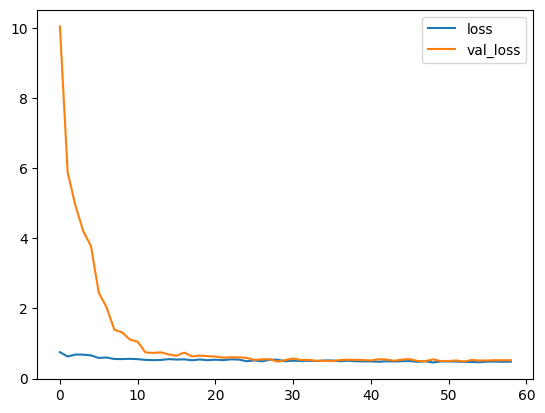

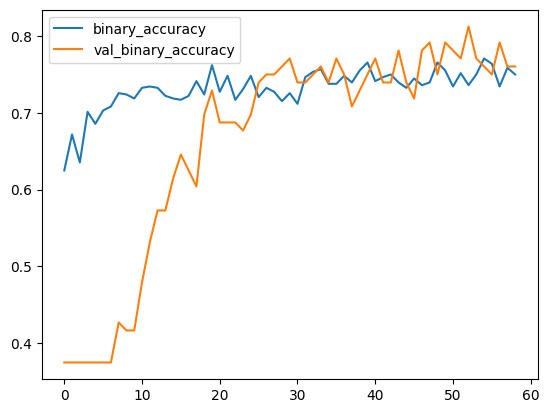

In [ ]:
history_df = pd.DataFrame(history.history)
# Start the plot at epoch 5
history_df.loc[0:, ['loss', 'val_loss']].plot()
history_df.loc[0:, ['binary_accuracy', 'val_binary_accuracy']].plot()

print(("Best Validation Loss: {:0.4f}" +\
      "\nBest Validation Accuracy: {:0.4f}")\
      .format(history_df['val_loss'].min(),
              history_df['val_binary_accuracy'].max()))

#### Veamos la matriz de confusión

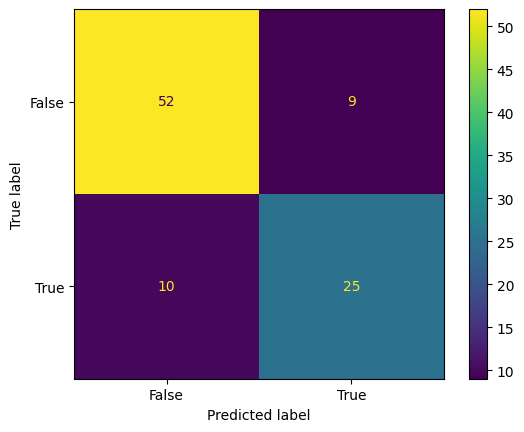

In [ ]:
from sklearn import metrics

actual = y_test
predicted = modelo.predict(X_test,verbose=0)
predicted = (predicted > threshold).astype('int')
confusion_matrix = metrics.confusion_matrix(actual, predicted)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

#### Curva ROC

Los thresholds utilizados son [0.982 0.819 0.809 0.735 0.677 0.625 0.59  0.577 0.562 0.535 0.452 0.443
 0.422 0.371 0.232 0.232 0.232 0.222 0.203 0.202 0.128 0.124 0.068 0.059
 0.057 0.046 0.021 0.02  0.002]


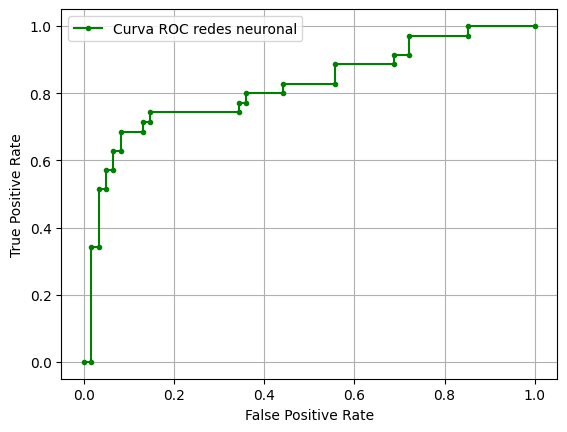

El área de la curva ROC es 0.8196721311475411


In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

prob = modelo.predict(X_test,verbose=0)
fper, tper, thresholds = roc_curve(y_test, prob)
roc_auc = roc_auc_score(y_test, prob)
print('Los thresholds utilizados son', np.round_(thresholds[1:],3))
roc_curve(y_test, prob)
plt.plot(fper, tper, marker='.', label='Curva ROC redes neuronal',color='g')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()
print('El área de la curva ROC es',roc_auc)

## Testeo de algunos ejemplos

In [ ]:
i = 14
j = 30
model_pred = modelo.predict(X_test.iloc[i:j],verbose=0)
for k in range(i,j):
  if model_pred[k-i][0] > threshold:
    pred = 1
  else: pred = 0
  print('La predicción da', pred, 'y el verdadero valor de la persona es', y_test.iloc[k])

La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 1 y el verdadero valor de la persona es 1
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 1
La predicción da 1 y el verdadero valor de la persona es 1
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 1 y el verdadero valor de la persona es 1
La predicción da 1 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0
La predicción da 0 y el verdadero valor de la persona es 0


# Usando Boosting Trees

In [ ]:
#Servirá para la visualización
!pip install -q -U dtreeviz

import dtreeviz
from dtreeviz.trees import *
from xgboost import plot_tree

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import MinMaxScaler

#Reescalar las columnas, no es necesario para decision tree, puede ser útil para boosting trees (como nuestro caso)
scaler = MinMaxScaler()
X_train_escalado = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns.tolist())
X_test_escalado = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns.tolist())

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

#Parámetros posibles:
#n_estimators = número de árboles
#Gamma = Minimum loss reduction required to make a further partition on a leaf node of the tree
model = XGBClassifier(n_estimators=200, gamma=0.01)

model.fit(X_train_escalado, y_train)
y_predict = model.predict(X_test_escalado)
#accuracy
accuracy_score(y_test,y_predict)

0.7604166666666666

#### Visualización de un árbol

In [ ]:
#Para visualizar tengo que usar datos no escalados
model_sin_escalar = XGBClassifier(n_estimators=200, gamma=0.01)

model_sin_escalar.fit(X_train, y_train)
y_predict_sin_escalar = model.predict(X_test)

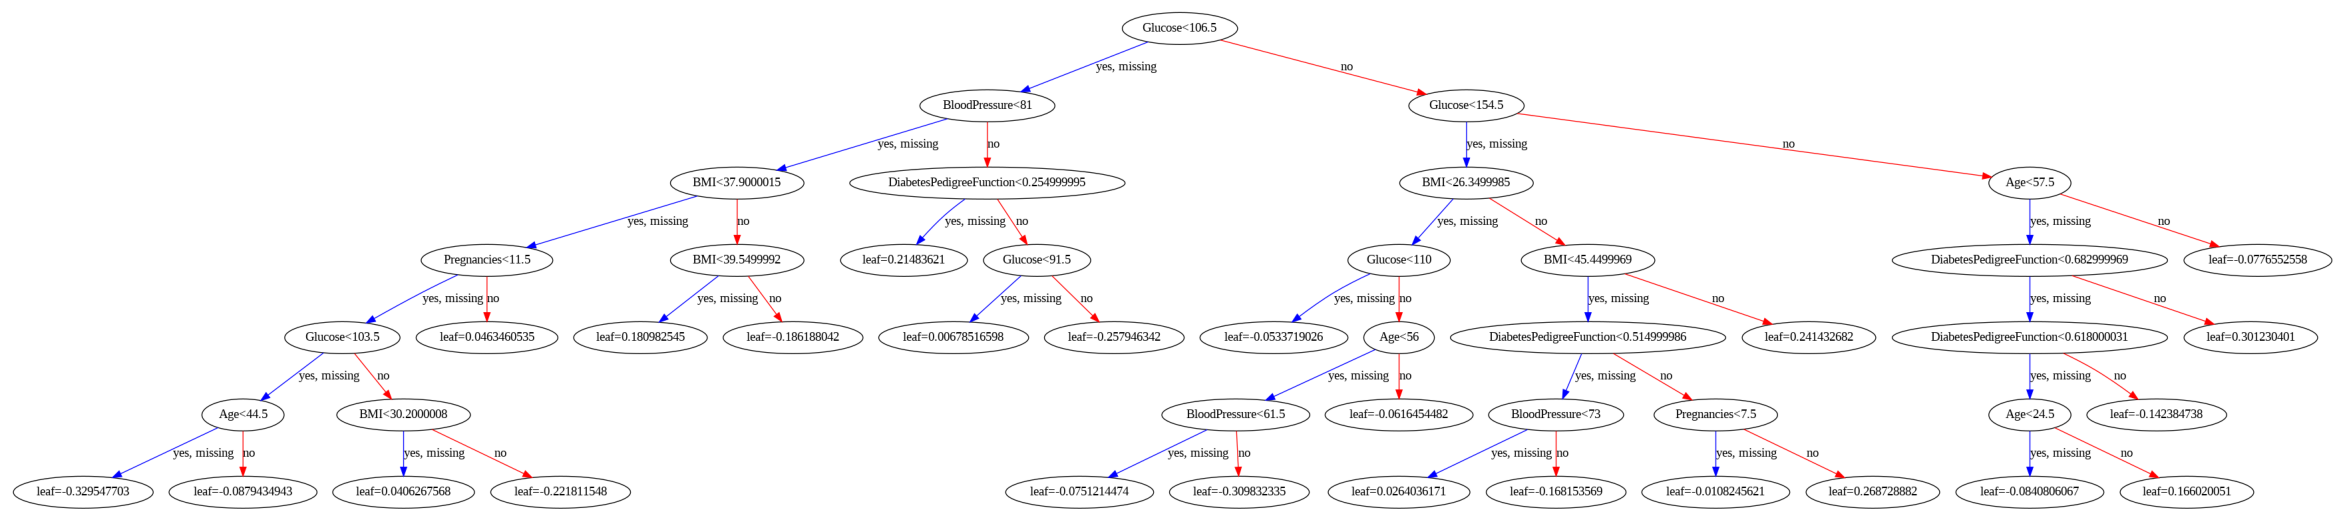

In [ ]:
num_tree = 5

fig, ax = plt.subplots(figsize=(30, 30))
plot_tree(model_sin_escalar, num_trees=num_tree, ax=ax,proportion=True)
plt.show()

### Las hojas finales son una predicción logística, para pasar a una predicción entre 0 y 1 hay que pasarla por una función, en este caso:
### f(x) = $\frac{1}{1+e^{x}}$

### Ahora veré otra forma de visualizar un árbol en específico

In [ ]:
viz_model = dtreeviz.model(model_sin_escalar,
                           tree_index=num_tree,
                           X_train=X_train,
                           y_train=y_train,
                           feature_names=X_train.columns.tolist(),
                           target_name='Output',
                           class_names=['No diabetes','Diabetes'])

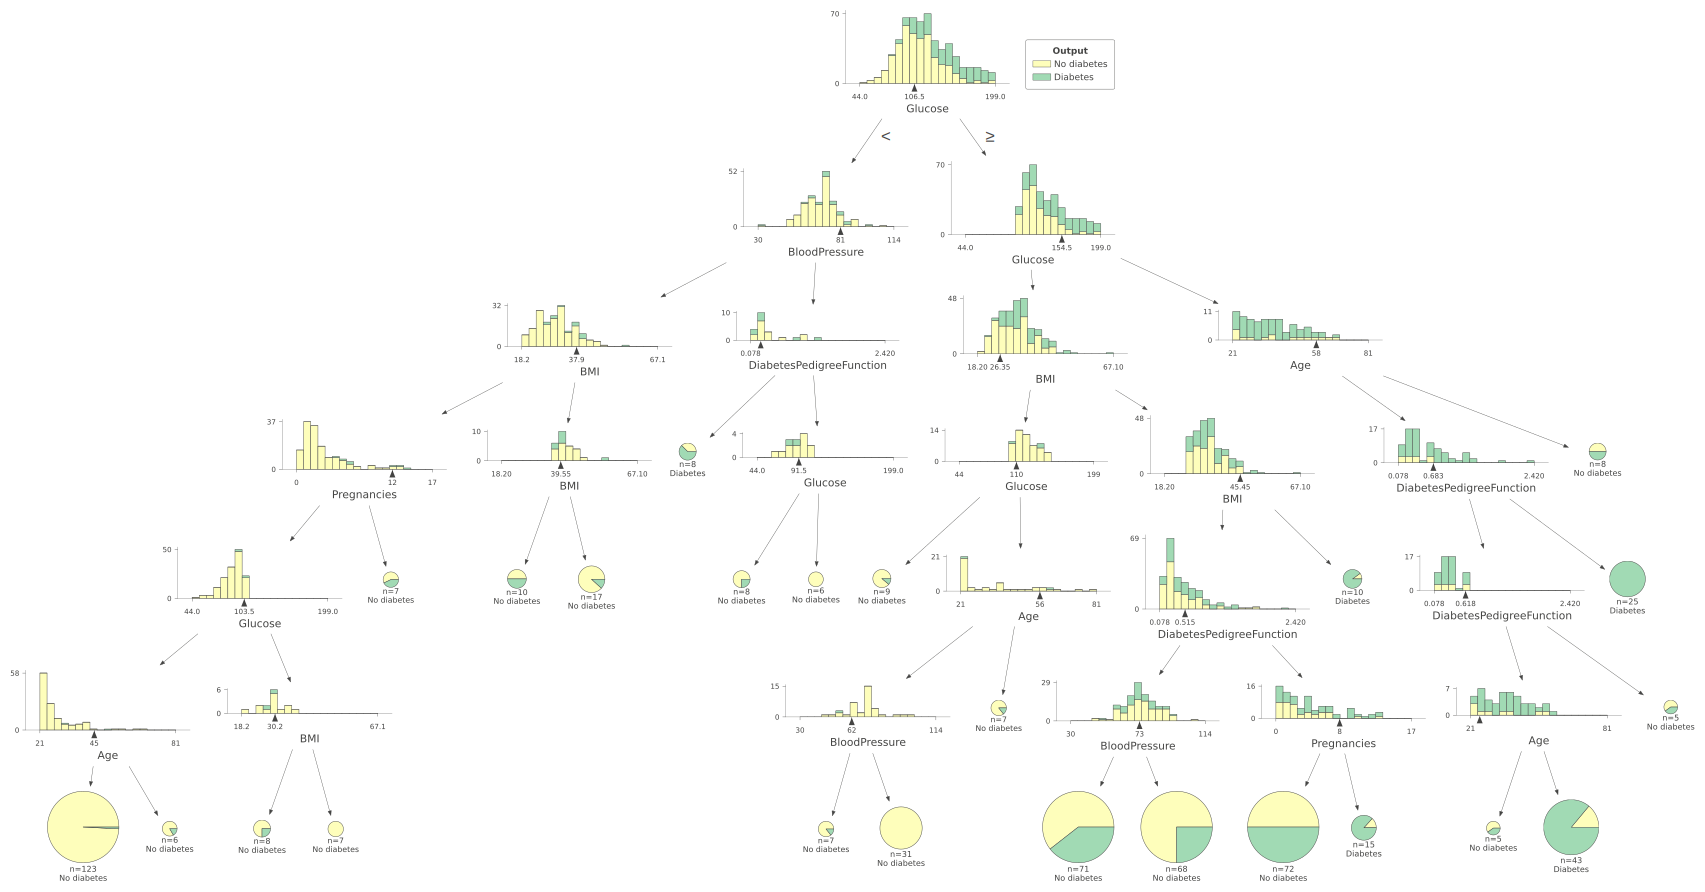

In [ ]:
# Elimina "Arial font not found warnings" que aparece al hacer la view
import logging
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.CRITICAL)
viz_model.view(scale=1.2)

### Matriz de Confusión y curva ROC

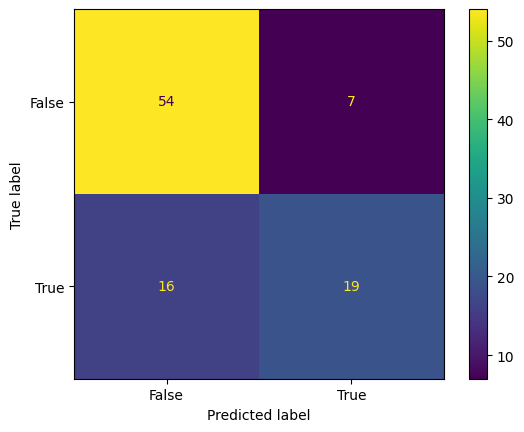

In [ ]:
actual = y_test
predicted = y_predict
confusion_matrix = metrics.confusion_matrix(actual, predicted)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

Los thresholds utilizados son [0.999 0.995 0.994 0.993 0.989 0.98  0.963 0.957 0.947 0.876 0.871 0.768
 0.715 0.664 0.593 0.525 0.394 0.351 0.261 0.127 0.043 0.042 0.026 0.025
 0.018 0.017 0.014 0.012 0.01  0.009 0.007 0.005 0.001 0.001 0.001 0.
 0.   ]


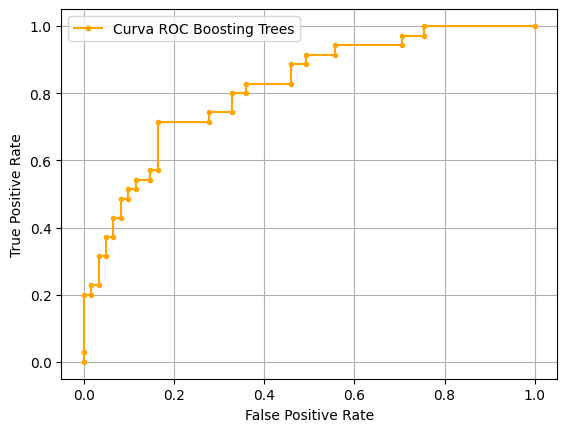

El área de la curva ROC es 0.8168618266978923


In [ ]:
y_predict = model.predict_proba(X_test_escalado)[:,1]
fper_2, tper_2, thresholds_2 = roc_curve(y_test, y_predict)
roc_auc = roc_auc_score(y_test, y_predict)
print('Los thresholds utilizados son', np.round_(thresholds_2[1:],3))
roc_curve(y_test, y_predict)
plt.plot(fper_2, tper_2, marker='.', label='Curva ROC Boosting Trees',color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()
print('El área de la curva ROC es',roc_auc)

## Testeemos algunas predicciones

In [ ]:
y_predict = model.predict(X_test_escalado)
for j in range(15):
  print("La predicción es %d y el valor real es %d" % (y_predict[j],y_test.iloc[j]))

La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 1
La predicción es 1 y el valor real es 1
La predicción es 1 y el valor real es 1
La predicción es 0 y el valor real es 1
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 1
La predicción es 1 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0
La predicción es 0 y el valor real es 0


## Regresión Logística

### Modelos

Se verán 3 modelos para luego elegir 1

In [ ]:
from sklearn.linear_model import LogisticRegression
#Solver 'liblinear' con penalty posibles = 'l1', 'l2'
#Solver 'lbfgs' con penalty posibles ='l2', None
# C = Inverse of regularization strength, tol = tolerancia
def modelo_log(i):
  if i==1:
    clf = LogisticRegression(random_state=0, max_iter=1000, penalty='l1', solver='liblinear', C=0.5, tol=1e-4)
    return clf
  if i==2:
    clf = LogisticRegression(random_state=0, max_iter=1000, penalty='l2', solver='liblinear', C=1, tol=1e-4)
    return clf
  if i==3:
    clf = LogisticRegression(random_state=0, max_iter=1000, penalty=None, solver='lbfgs', tol=1e-4)
    return clf

### Hagamos una k-fold Cross Validation para ver con qué modelo quedarse

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# CV model
# Sólo se puede pasar una métrica a la vez en cross_val_score
kfold = KFold(n_splits=7)
modelos = ['Modelo 1:','Modelo 2:', 'Modelo 3:']
for i in range(3):
  print(modelos[i])
  clf = modelo_log(i+1)
  results_accuracy = cross_val_score(clf, X_train_escalado, y_train, cv=kfold, scoring='accuracy')
  results_f1 = cross_val_score(clf, X_train_escalado, y_train, cv=kfold, scoring='f1')
  results_precision = cross_val_score(clf, X_train_escalado, y_train, cv=kfold, scoring='precision')
  results_recall = cross_val_score(clf, X_train_escalado, y_train, cv=kfold, scoring='recall')
  for j in range(7):
    print('Accuracy %.2f, f1_score %.2f, precisión %.2f y recall %.2f' % (results_accuracy[j], results_f1[j], results_precision[j], results_recall[j]))
  print("Medias (desvío): Accuracy %.2f%% (%.2f%%), f1_score %.2f%% (%.2f%%), precisión %.2f%% (%.2f%%) y recall %.2f%% (%.2f%%)\n" % (results_accuracy.mean()*100, results_accuracy.std()*100,results_f1.mean()*100, results_f1.std()*100,results_precision.mean()*100, results_precision.std()*100,results_recall.mean()*100, results_recall.std()*100))

Modelo 1:
Accuracy 0.77, f1_score 0.68, precisión 0.83 y recall 0.57
Accuracy 0.76, f1_score 0.57, precisión 0.68 y recall 0.48
Accuracy 0.74, f1_score 0.57, precisión 0.64 y recall 0.52
Accuracy 0.77, f1_score 0.60, precisión 0.70 y recall 0.52
Accuracy 0.79, f1_score 0.59, precisión 0.86 y recall 0.44
Accuracy 0.68, f1_score 0.41, precisión 0.43 y recall 0.39
Accuracy 0.76, f1_score 0.60, precisión 0.79 y recall 0.48
Medias (desvío): Accuracy 75.34% (3.20%), f1_score 57.21% (7.50%), precisión 70.42% (13.54%) y recall 48.71% (5.36%)

Modelo 2:
Accuracy 0.76, f1_score 0.66, precisión 0.83 y recall 0.54
Accuracy 0.78, f1_score 0.61, precisión 0.74 y recall 0.52
Accuracy 0.77, f1_score 0.60, precisión 0.70 y recall 0.52
Accuracy 0.78, f1_score 0.63, precisión 0.71 y recall 0.56
Accuracy 0.77, f1_score 0.54, precisión 0.79 y recall 0.41
Accuracy 0.72, f1_score 0.47, precisión 0.50 y recall 0.43
Accuracy 0.76, f1_score 0.62, precisión 0.76 y recall 0.52
Medias (desvío): Accuracy 76.21% (1.

### Se elige el modelo 3 y se lo entrena

In [ ]:
cfl = modelo_log(3)
cfl.fit(X_train_escalado,y_train)
#Score
cfl.score(X_test_escalado,y_test)

0.8020833333333334

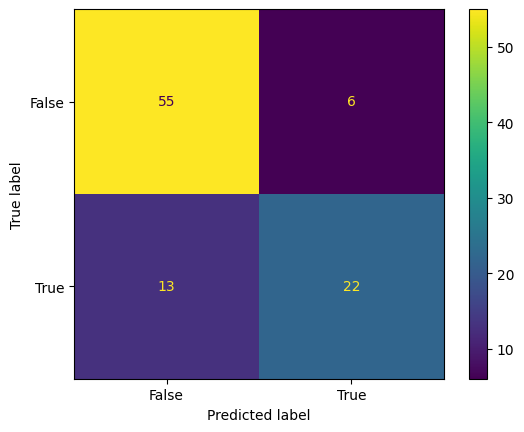

In [ ]:
from sklearn import metrics

#matriz de confusión
actual = y_test
predicted = cfl.predict(X_test_escalado)
confusion_matrix = metrics.confusion_matrix(actual, predicted)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

Los thresholds utilizados son [0.993 0.883 0.875 0.704 0.683 0.665 0.636 0.572 0.567 0.49  0.481 0.474
 0.33  0.307 0.304 0.303 0.272 0.26  0.245 0.237 0.235 0.198 0.167 0.147
 0.107 0.099 0.035 0.031 0.005]


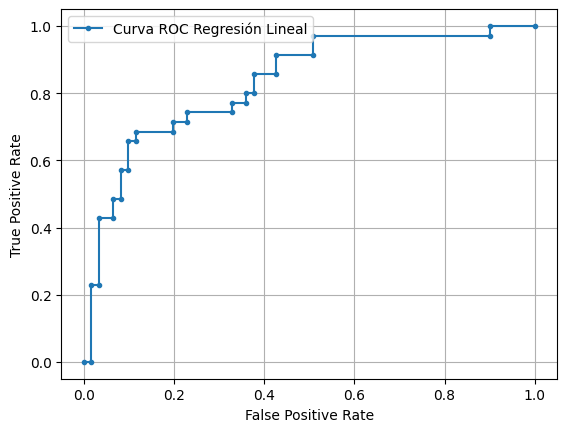

El área de la curva ROC es 0.8346604215456674


In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
y_predict = cfl.predict_proba(X_test_escalado)[:,1]
fper_3, tper_3, thresholds_3 = roc_curve(y_test, y_predict)
roc_auc = roc_auc_score(y_test, y_predict)
print('Los thresholds utilizados son', np.round_(thresholds_3[1:],3))
roc_curve(y_test, y_predict)
plt.plot(fper_3, tper_3, marker='.', label='Curva ROC Regresión Lineal')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()
print('El área de la curva ROC es',roc_auc)

# Conclusión

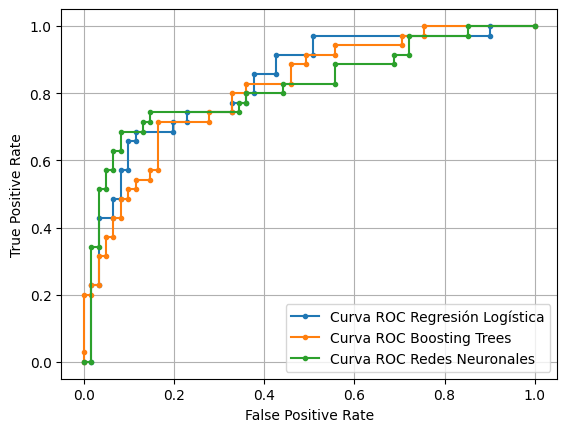

In [ ]:
#Veo todas las curvas ROC
plt.plot(fper_3, tper_3, marker='.', label='Curva ROC Regresión Logística')
plt.plot(fper_2, tper_2, marker='.', label='Curva ROC Boosting Trees')
plt.plot(fper, tper, marker='.', label='Curva ROC Redes Neuronales')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

Las tres variaciones obtienen resultados parecidos. Para mejorar los modelos se podría ver en particular los casos en los que clasifica mal y ver si hay un patrón, si los modelos suelen clasificar mal cierto tipo de datos, si serían considerados outliers o no. El objetivo es poder generalizar futuros pacientes entonces siempre está bueno cubrir todos los posibles escenarios